<div style="background: #1a1a1a; padding: 30px; text-align: center; border-radius: 8px;">
    <div style="font-size: 32px; font-weight: bold; margin-bottom: 15px; background: linear-gradient(135deg, rgb(151, 205, 157) 0%, rgba(167, 245, 255, 0.97) 100%); -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text;">Mini-Project 1: Advanced Data Mining</div>
    <div style="font-size: 18px; font-weight: bold; margin-bottom: 3px; color: #ddd;">RNN — Multivariate Weather Forecasting on Jena Climate</div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 16px; margin-bottom: 8px; color: #ddd;"><strong>Task:</strong> multi-step temperature forecasting with LSTM, GRU, and Seq2Seq recurrent models.</div>
    <div style="font-size: 16px; margin-bottom: 12px; color: #ddd;"><strong>Original Contribution — Hypothesis</strong></div>
    <div style="background: rgba(255,255,255,0.05); border-left: 3px solid rgb(151, 205, 157); padding: 15px 20px; margin: 10px 0 8px 0; border-radius: 4px; text-align: left;">
        <div style="font-size: 15px; margin-bottom: 8px; color: #ddd; font-style: italic; line-height: 1.6;">"Change-aware training will reduce MAE during rapid temperature transitions without materially degrading performance during stable periods."</div>
        <div style="font-size: 13px; color: #aaa; line-height: 1.5;">Change-Aware Training gives more training emphasis to rapid-temperature-change windows.</div>
    </div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 16px; margin-bottom: 3px; color: #ddd;">Professor: Dr. Hadi Farahani</div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 16px; margin-bottom: 3px; color: #ddd;">Head TA: Mr. Mobin Nesari</div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 16px; margin-bottom: 5px; color: #ddd;">Student: Alireza Jahanbakhsh</div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 14px; color: #aaa;">Date: August 12, 2026 | Course: Data Mining</div>
</div>

# RNN — Multivariate Weather Forecasting on Jena Climate


## 1. Problem and Experimental Design

### 1.1 Research design
We forecast the next 24 hourly temperatures from the previous 72 hours of multivariate weather observations, using leakage-free chronological evaluation.

### 1.2 Original contribution and hypothesis
We first diagnose whether rapid temperature transitions are a failure mode, then test a targeted fix: up-weighting rapid-change training windows. Statistical inference is reserved for a non-overlapping test subset.

In [1]:
import os
import random
import shutil
import time
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scipy import stats

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

def reset_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

reset_seeds()

FIG_DIR = "/kaggle/working/figures"
RES_DIR = "/kaggle/working/results"
MODEL_DIR = "/kaggle/working/models"

for directory in [FIG_DIR, RES_DIR, MODEL_DIR]:
    if os.path.exists(directory):
        shutil.rmtree(directory)
    os.makedirs(directory, exist_ok=True)

def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=180, bbox_inches="tight")

print("TensorFlow:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.20.0
GPU available: True


## 2. Data Loading and Preprocessing

In [2]:
def find_local_csv():
    candidates = []
    for root, _, files in os.walk("/kaggle/input"):
        for filename in files:
            if filename.lower().endswith(".csv") and "jena" in filename.lower():
                candidates.append(os.path.join(root, filename))
    return sorted(candidates)[0] if candidates else None

csv_path = find_local_csv()

if csv_path is None:
    zip_path = keras.utils.get_file(
        fname="jena_climate_2009_2016.csv.zip",
        origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
        extract=True
    )
    base = os.path.dirname(zip_path)
    csv_path = os.path.join(base, "jena_climate_2009_2016.csv")
    if not os.path.exists(csv_path):
        csv_path = zip_path.replace(".zip", "")

df = pd.read_csv(csv_path)
print("CSV:", csv_path)
print("Raw shape:", df.shape)
df.head()

CSV: /kaggle/input/datasets/mnassrib/jena-climate/jena_climate_2009_2016.csv
Raw shape: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [3]:
df["Date Time"] = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")
df = df.set_index("Date Time").iloc[5::6].copy()

for column in ["wv (m/s)", "max. wv (m/s)"]:
    if column in df.columns:
        df.loc[df[column] < -9000, column] = 0.0

TARGET = "T (degC)"
FEATURES = df.columns.tolist()

print("Hourly shape:", df.shape)
print("Features:", len(FEATURES))
print("Target:", TARGET)

Hourly shape: (70091, 14)
Features: 14
Target: T (degC)


### 2.1 Dataset overview

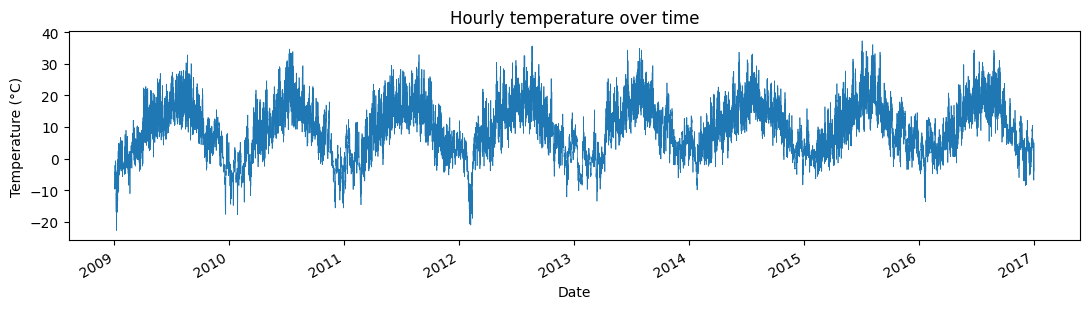

,T (degC),p (mbar),rh (%)
count,70091.000,70091.000,70091.000
mean,9.450,989.213,76.010
std,8.423,8.359,16.475
min,-22.760,913.600,13.880
25%,3.350,984.200,65.210
50%,9.410,989.570,79.300
75%,15.480,994.720,89.400
max,37.280,1015.290,100.000


In [4]:
plt.figure(figsize=(11, 3.2))
df[TARGET].plot(lw=0.5)
plt.title("Hourly temperature over time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
savefig("01_temperature_timeseries.png")
plt.show()

display(df[[TARGET, "p (mbar)", "rh (%)"]].describe().round(3))

### 2.2 Chronological split and train-only scaling
The first 70% is training data, the next 15% validation, and the final 15% test. Scaling parameters are estimated only from training data.

In [5]:
n = len(df)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

train_df = df.iloc[:n_train]
val_df = df.iloc[n_train:n_train + n_val]
test_df = df.iloc[n_train + n_val:]

feat_mean = train_df[FEATURES].mean()
feat_std = train_df[FEATURES].std().replace(0, 1)

def scale_frame(frame):
    return ((frame[FEATURES] - feat_mean) / feat_std).astype("float32")

train_s = scale_frame(train_df)
val_s = scale_frame(val_df)
test_s = scale_frame(test_df)

target_idx = FEATURES.index(TARGET)
t_mean = float(feat_mean[TARGET])
t_std = float(feat_std[TARGET])

print("Train:", train_df.shape, train_df.index.min(), "→", train_df.index.max())
print("Validation:", val_df.shape, val_df.index.min(), "→", val_df.index.max())
print("Test:", test_df.shape, test_df.index.min(), "→", test_df.index.max())

Train: (49063, 14) 2009-01-01 01:00:00 → 2014-08-05 01:10:00
Validation: (10513, 14) 2014-08-05 02:10:00 → 2015-10-17 18:00:00
Test: (10515, 14) 2015-10-17 19:00:00 → 2016-12-31 23:10:00


### 2.3 Sliding windows
Each sample uses 72 past hourly observations and predicts the next 24 hourly temperatures.

In [6]:
IN_LEN = 72
OUT_LEN = 24

def make_windows(data, in_len, out_len, target_index, stride=1):
    arr = data.values.astype("float32")
    X, y = [], []
    last = len(arr) - in_len - out_len + 1
    for start in range(0, last, stride):
        X.append(arr[start:start + in_len])
        y.append(arr[start + in_len:start + in_len + out_len, target_index])
    return np.asarray(X, dtype="float32"), np.asarray(y, dtype="float32")

X_train, y_train = make_windows(train_s, IN_LEN, OUT_LEN, target_idx)
X_val, y_val = make_windows(val_s, IN_LEN, OUT_LEN, target_idx)
X_test, y_test = make_windows(test_s, IN_LEN, OUT_LEN, target_idx)

N_FEAT = X_train.shape[-1]

print("Train windows:", X_train.shape, y_train.shape)
print("Validation windows:", X_val.shape, y_val.shape)
print("Test windows:", X_test.shape, y_test.shape)

Train windows: (48968, 72, 14) (48968, 24)
Validation windows: (10418, 72, 14) (10418, 24)
Test windows: (10420, 72, 14) (10420, 24)


## 3. Forecasting Baselines

In [7]:
def to_celsius(values):
    return values * t_std + t_mean

def horizon_metrics(pred_c, true_c):
    mae = np.mean(np.abs(pred_c - true_c), axis=0)
    rmse = np.sqrt(np.mean((pred_c - true_c) ** 2, axis=0))
    return mae, rmse

y_val_c = to_celsius(y_val)
y_test_c = to_celsius(y_test)

last_val_c = to_celsius(X_val[:, -1, target_idx])
last_test_c = to_celsius(X_test[:, -1, target_idx])

pred_persistence_val = np.repeat(last_val_c[:, None], OUT_LEN, axis=1)
pred_persistence_test = np.repeat(last_test_c[:, None], OUT_LEN, axis=1)

pred_seasonal_val = to_celsius(X_val[:, -OUT_LEN:, target_idx])
pred_seasonal_test = to_celsius(X_test[:, -OUT_LEN:, target_idx])

persistence_mae, persistence_rmse = horizon_metrics(pred_persistence_test, y_test_c)
seasonal_mae, seasonal_rmse = horizon_metrics(pred_seasonal_test, y_test_c)

print("Persistence mean MAE:", round(float(persistence_mae.mean()), 3))
print("Seasonal-naive mean MAE:", round(float(seasonal_mae.mean()), 3))

Persistence mean MAE: 3.157
Seasonal-naive mean MAE: 2.507


### 3.1 Recurrent architectures

In [8]:
UNITS = 64

def build_lstm():
    return keras.Sequential([
        layers.Input((IN_LEN, N_FEAT)),
        layers.LSTM(UNITS),
        layers.Dense(OUT_LEN)
    ], name="LSTM")

def build_gru():
    return keras.Sequential([
        layers.Input((IN_LEN, N_FEAT)),
        layers.GRU(UNITS),
        layers.Dense(OUT_LEN)
    ], name="GRU")

def build_seq2seq():
    inp = layers.Input((IN_LEN, N_FEAT))
    enc = layers.LSTM(UNITS)(inp)
    dec = layers.RepeatVector(OUT_LEN)(enc)
    dec = layers.LSTM(UNITS, return_sequences=True)(dec)
    out = layers.TimeDistributed(layers.Dense(1))(dec)
    out = layers.Reshape((OUT_LEN,))(out)
    return keras.Model(inp, out, name="Seq2Seq")

build_seq2seq().summary()

I0000 00:00:1786792310.407071      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786792310.413242      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Seq2Seq"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 72, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 24)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,313 (208.25 KB)

 Trainable params: 53,313 (208.25 KB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Common training protocol

In [9]:
EPOCHS = 20
BATCH = 128
PATIENCE = 4
training_seconds = {}

def train_model(build_fn, tag, sample_weight=None, seed=SEED):
    reset_seeds(seed)
    model = build_fn()
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    callback = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True
    )
    start = time.perf_counter()
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        sample_weight=sample_weight,
        epochs=EPOCHS,
        batch_size=BATCH,
        callbacks=[callback],
        verbose=2
    )
    training_seconds[tag] = time.perf_counter() - start
    print("Completed:", tag)
    print("Training seconds:", round(training_seconds[tag], 2))
    return model, history

def predict_celsius(model, X):
    return to_celsius(model.predict(X, batch_size=256, verbose=0))


In [10]:
lstm_model, lstm_hist = train_model(build_lstm, "LSTM")
gru_model, gru_hist = train_model(build_gru, "GRU")
seq2seq_model, seq2seq_hist = train_model(build_seq2seq, "Seq2Seq")

Epoch 1/20
383/383 - 6s - 15ms/step - loss: 0.1569 - val_loss: 0.0976
Epoch 2/20
383/383 - 3s - 7ms/step - loss: 0.0864 - val_loss: 0.0909
Epoch 3/20
383/383 - 3s - 7ms/step - loss: 0.0788 - val_loss: 0.0870
Epoch 4/20
383/383 - 3s - 7ms/step - loss: 0.0738 - val_loss: 0.0855
Epoch 5/20
383/383 - 3s - 7ms/step - loss: 0.0705 - val_loss: 0.0852
Epoch 6/20
383/383 - 3s - 7ms/step - loss: 0.0677 - val_loss: 0.0853
Epoch 7/20
383/383 - 3s - 7ms/step - loss: 0.0650 - val_loss: 0.0856
Epoch 8/20
383/383 - 3s - 7ms/step - loss: 0.0624 - val_loss: 0.0859
Epoch 9/20
383/383 - 3s - 7ms/step - loss: 0.0598 - val_loss: 0.0875
Completed: LSTM
Training seconds: 27.32
Epoch 1/20
383/383 - 4s - 10ms/step - loss: 0.1566 - val_loss: 0.0956
Epoch 2/20
383/383 - 2s - 6ms/step - loss: 0.0878 - val_loss: 0.0901
Epoch 3/20
383/383 - 2s - 6ms/step - loss: 0.0823 - val_loss: 0.0874
Epoch 4/20
383/383 - 2s - 6ms/step - loss: 0.0788 - val_loss: 0.0854
Epoch 5/20
383/383 - 2s - 6ms/step - loss: 0.0763 - val_loss:

### 3.3 Training curves

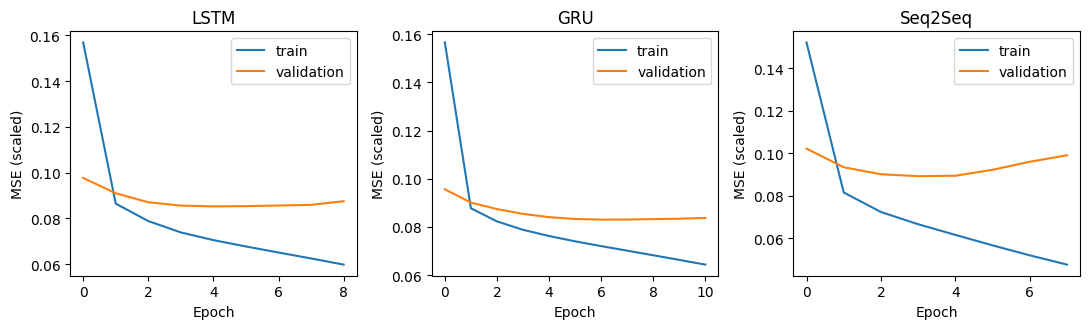

In [11]:
histories = {"LSTM": lstm_hist, "GRU": gru_hist, "Seq2Seq": seq2seq_hist}

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, (name, history) in zip(axes, histories.items()):
    ax.plot(history.history["loss"], label="train")
    ax.plot(history.history["val_loss"], label="validation")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE (scaled)")
    ax.legend()

plt.tight_layout()
savefig("02_training_curves.png")
plt.show()

## 4. Baseline Evaluation

In [12]:
pred_lstm_test = predict_celsius(lstm_model, X_test)
pred_gru_test = predict_celsius(gru_model, X_test)
pred_seq2seq_test = predict_celsius(seq2seq_model, X_test)

baseline_predictions = {
    "Persistence": pred_persistence_test,
    "SeasonalNaive": pred_seasonal_test,
    "LSTM": pred_lstm_test,
    "GRU": pred_gru_test,
    "Seq2Seq": pred_seq2seq_test
}

baseline_metrics = {}
for name, pred in baseline_predictions.items():
    baseline_metrics[name] = horizon_metrics(pred, y_test_c)

rows = []
for h in range(OUT_LEN):
    row = {"horizon_h": h + 1}
    for name, (mae, rmse) in baseline_metrics.items():
        row[f"{name}_MAE"] = mae[h]
        row[f"{name}_RMSE"] = rmse[h]
    rows.append(row)

horizon_df = pd.DataFrame(rows)
horizon_df.to_csv(os.path.join(RES_DIR, "baseline_metrics_per_horizon.csv"), index=False)
horizon_df.round(3).head()

,horizon_h,Persistence_MAE,Persistence_RMSE,SeasonalNaive_MAE,SeasonalNaive_RMSE,LSTM_MAE,LSTM_RMSE,GRU_MAE,GRU_RMSE,Seq2Seq_MAE,Seq2Seq_RMSE
0,1,0.677,0.961,2.507,3.257,0.636,0.852,0.554,0.749,0.781,1.013
1,2,1.232,1.707,2.507,3.257,0.882,1.171,0.837,1.114,0.953,1.251
2,3,1.745,2.388,2.507,3.257,1.115,1.478,1.082,1.424,1.145,1.499
3,4,2.219,3.004,2.507,3.257,1.297,1.690,1.261,1.652,1.312,1.704
4,5,2.645,3.549,2.507,3.257,1.443,1.869,1.421,1.840,1.450,1.873


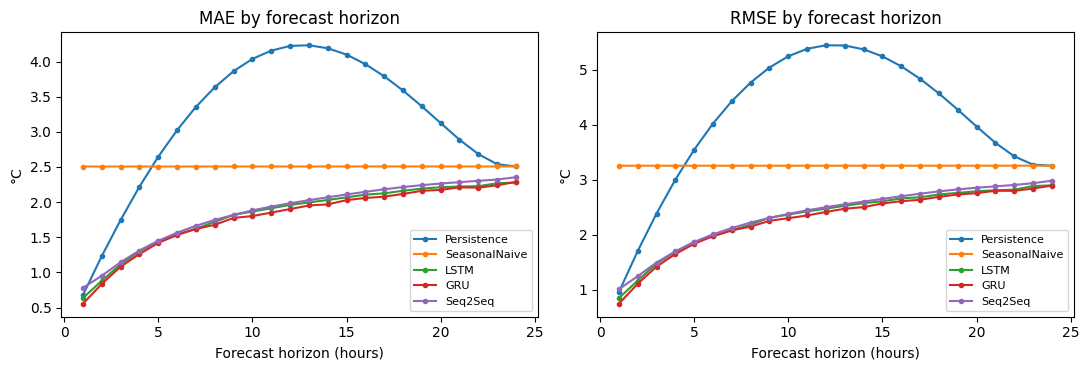

In [13]:
hx = np.arange(1, OUT_LEN + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for name, (mae, rmse) in baseline_metrics.items():
    axes[0].plot(hx, mae, marker=".", label=name)
    axes[1].plot(hx, rmse, marker=".", label=name)

axes[0].set_title("MAE by forecast horizon")
axes[1].set_title("RMSE by forecast horizon")

for ax in axes:
    ax.set_xlabel("Forecast horizon (hours)")
    ax.set_ylabel("°C")
    ax.legend(fontsize=8)

plt.tight_layout()
savefig("03_baseline_metrics_vs_horizon.png")
plt.show()

In [14]:
summary_rows = []
for name, (mae, rmse) in baseline_metrics.items():
    summary_rows.append({
        "model": name,
        "MAE_mean": mae.mean(),
        "RMSE_mean": rmse.mean(),
        "MAE_h1": mae[0],
        "MAE_h24": mae[-1]
    })

baseline_summary = pd.DataFrame(summary_rows).sort_values("MAE_mean").reset_index(drop=True)
baseline_summary.to_csv(os.path.join(RES_DIR, "baseline_summary.csv"), index=False)
baseline_summary.round(3)

,model,MAE_mean,RMSE_mean,MAE_h1,MAE_h24
0,GRU,1.783,2.277,0.554,2.288
1,LSTM,1.821,2.320,0.636,2.280
2,Seq2Seq,1.865,2.367,0.781,2.355
3,SeasonalNaive,2.507,3.258,2.507,2.507
4,Persistence,3.157,4.098,0.677,2.507


### 4.1 Example forecasts

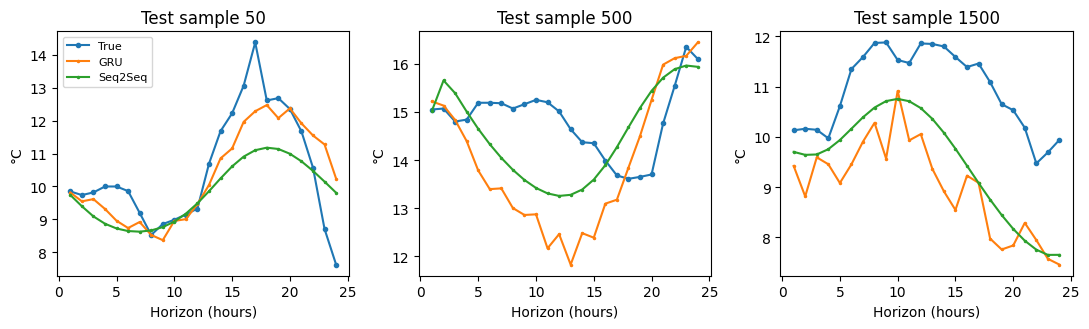

In [15]:
example_ids = [50, 500, 1500]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, sample_id in zip(axes, example_ids):
    ax.plot(hx, y_test_c[sample_id], marker="o", ms=3, label="True")
    ax.plot(hx, pred_gru_test[sample_id], marker=".", ms=3, label="GRU")
    ax.plot(hx, pred_seq2seq_test[sample_id], marker=".", ms=3, label="Seq2Seq")
    ax.set_title(f"Test sample {sample_id}")
    ax.set_xlabel("Horizon (hours)")
    ax.set_ylabel("°C")

axes[0].legend(fontsize=8)
plt.tight_layout()
savefig("04_example_forecasts.png")
plt.show()

### 4.2 Statistical comparison of baseline forecasts
To reduce dependence caused by overlapping windows, inferential tests use windows separated by at least `IN_LEN + OUT_LEN` hours. A Friedman test first evaluates whether the forecasting methods differ overall; Holm-adjusted paired Wilcoxon tests are used only for post-hoc pairwise comparisons.


In [16]:
STAT_STEP = IN_LEN + OUT_LEN
stat_idx = np.arange(0, len(y_test_c), STAT_STEP)

sample_mae_table = pd.DataFrame({
    name: np.mean(np.abs(pred[stat_idx] - y_test_c[stat_idx]), axis=1)
    for name, pred in baseline_predictions.items()
})

friedman = stats.friedmanchisquare(*[sample_mae_table[c].values for c in sample_mae_table.columns])

def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)
    running = 0.0
    m = len(p_values)
    for rank, idx in enumerate(order):
        value = min(1.0, (m - rank) * p_values[idx])
        running = max(running, value)
        adjusted[idx] = running
    return adjusted

pairs = []
raw_p = []
for a, b in itertools.combinations(sample_mae_table.columns, 2):
    result = stats.wilcoxon(sample_mae_table[a], sample_mae_table[b], alternative="two-sided")
    pairs.append((a, b, result.statistic, result.pvalue))
    raw_p.append(result.pvalue)

adjusted_p = holm_adjust(raw_p)

posthoc_rows = []
for (a, b, statistic, p_raw), p_adj in zip(pairs, adjusted_p):
    posthoc_rows.append({
        "model_A": a,
        "model_B": b,
        "median_MAE_A": np.median(sample_mae_table[a]),
        "median_MAE_B": np.median(sample_mae_table[b]),
        "W": statistic,
        "p_raw": p_raw,
        "p_Holm": p_adj,
        "significant_0.05": p_adj < 0.05
    })

baseline_stats = pd.DataFrame(posthoc_rows).sort_values("p_Holm")
baseline_stats.to_csv(os.path.join(RES_DIR, "baseline_pairwise_wilcoxon_holm.csv"), index=False)

print("Independent-style non-overlapping evaluation windows:", len(stat_idx))
print("Friedman chi-square:", round(float(friedman.statistic), 4))
print("Friedman p-value:", f"{friedman.pvalue:.6g}")
baseline_stats.round(4)

Independent-style non-overlapping evaluation windows: 109
Friedman chi-square: 85.8202
Friedman p-value: 1.01613e-17


,model_A,model_B,median_MAE_A,median_MAE_B,W,p_raw,p_Holm,significant_0.05
2,Persistence,GRU,2.6925,1.6036,756.0,0.0000,0.0000,True
5,SeasonalNaive,GRU,2.3983,1.6036,889.0,0.0000,0.0000,True
1,Persistence,LSTM,2.6925,1.6034,918.0,0.0000,0.0000,True
3,Persistence,Seq2Seq,2.6925,1.6165,943.0,0.0000,0.0000,True
4,SeasonalNaive,LSTM,2.3983,1.6034,1078.0,0.0000,0.0000,True
6,SeasonalNaive,Seq2Seq,2.3983,1.6165,1425.0,0.0000,0.0000,True
0,Persistence,SeasonalNaive,2.6925,2.3983,2189.0,0.0145,0.0576,False
9,GRU,Seq2Seq,1.6036,1.6165,2188.0,0.0144,0.0576,False
8,LSTM,Seq2Seq,1.6034,1.6165,2364.0,0.0555,0.1109,False
7,LSTM,GRU,1.6034,1.6036,2473.0,0.1128,0.1128,False


## 5. Failure-Mode Diagnosis: Rapid Temperature Change
The contribution is motivated only if rapid temperature transitions are empirically associated with larger forecasting errors.

In [17]:
def change_score(last_observed_c, future_c):
    path = np.concatenate([last_observed_c[:, None], future_c], axis=1)
    return np.mean(np.abs(np.diff(path, axis=1)), axis=1)

train_last_c = to_celsius(X_train[:, -1, target_idx])
val_last_c = to_celsius(X_val[:, -1, target_idx])

train_change = change_score(train_last_c, to_celsius(y_train))
val_change = change_score(val_last_c, y_val_c)
test_change = change_score(last_test_c, y_test_c)

gru_sample_mae = np.mean(np.abs(pred_gru_test - y_test_c), axis=1)

rapid_threshold = float(np.quantile(train_change, 0.75))

print("Train-derived rapid-change threshold:", round(rapid_threshold, 4), "°C mean absolute hourly change")
print("Rapid test-window share:", round(float(np.mean(test_change >= rapid_threshold)), 3))

Train-derived rapid-change threshold: 0.9692 °C mean absolute hourly change
Rapid test-window share: 0.185


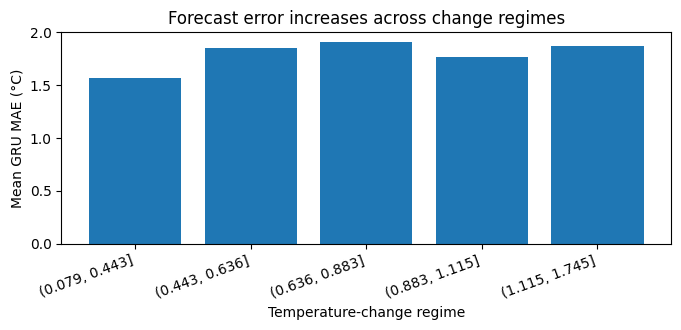

,change_regime,count,mean,median
0,"(0.079, 0.443]",2605,1.565,1.421
1,"(0.443, 0.636]",2606,1.852,1.649
2,"(0.636, 0.883]",2604,1.905,1.691
3,"(0.883, 1.115]",1563,1.769,1.559
4,"(1.115, 1.745]",1042,1.872,1.682


In [18]:
quantile_edges = np.unique(np.quantile(test_change, [0, 0.25, 0.50, 0.75, 0.90, 1.0]))
regime_ids = pd.cut(test_change, bins=quantile_edges, include_lowest=True, duplicates="drop")
regime_df = pd.DataFrame({"change_regime": regime_ids, "GRU_MAE": gru_sample_mae})
regime_summary = regime_df.groupby("change_regime", observed=True)["GRU_MAE"].agg(["count", "mean", "median"]).reset_index()
regime_summary.to_csv(os.path.join(RES_DIR, "failure_mode_error_by_change_regime.csv"), index=False)

plt.figure(figsize=(7, 3.4))
plt.bar(np.arange(len(regime_summary)), regime_summary["mean"])
plt.xticks(np.arange(len(regime_summary)), [str(x) for x in regime_summary["change_regime"]], rotation=20, ha="right")
plt.ylabel("Mean GRU MAE (°C)")
plt.xlabel("Temperature-change regime")
plt.title("Forecast error increases across change regimes")
plt.tight_layout()
savefig("05_error_by_change_regime.png")
plt.show()

regime_summary.round(3)

### 5.1 Statistical evidence for the failure mode
Spearman correlation tests whether stronger temperature transitions are monotonically associated with larger GRU forecast errors on non-overlapping evaluation windows.


In [19]:
diag_idx = stat_idx
diag_change = test_change[diag_idx]
diag_error = gru_sample_mae[diag_idx]

spearman = stats.spearmanr(diag_change, diag_error)

failure_tests = pd.DataFrame([{
    "test": "Spearman change-vs-error",
    "statistic": spearman.statistic,
    "p_value": spearman.pvalue,
    "interpretation": "Positive association" if spearman.statistic > 0 and spearman.pvalue < 0.05 else "No significant positive association"
}])

failure_tests.to_csv(os.path.join(RES_DIR, "failure_mode_statistical_tests.csv"), index=False)
failure_tests.round(5)


,test,statistic,p_value,interpretation
0,Spearman change-vs-error,0.2129,0.02624,Positive association


## 6. Original Contribution: Change-Aware Training

### 6.1 Method
Training windows above the 75th percentile of the **training** change-score distribution receive greater sample weight. The threshold is never estimated from validation or test data.

### 6.2 Hypothesis
**H1:** Compared with standard GRU training, change-aware weighting will significantly reduce MAE on rapid-change test windows while keeping stable-regime MAE degradation within 5%.

In [20]:
def make_change_weights(change_values, threshold, rapid_factor):
    weights = np.where(change_values >= threshold, rapid_factor, 1.0).astype("float32")
    return weights / weights.mean()

weight_schemes = {
    "uniform": 1.0,
    "mild": 1.5,
    "strong": 2.0
}

train_weights = {
    name: make_change_weights(train_change, rapid_threshold, factor)
    for name, factor in weight_schemes.items()
}

weight_summary = pd.DataFrame({
    name: {
        "rapid_factor": weight_schemes[name],
        "mean_weight": float(weights.mean()),
        "min_weight": float(weights.min()),
        "max_weight": float(weights.max())
    }
    for name, weights in train_weights.items()
}).T

weight_summary

,rapid_factor,mean_weight,min_weight,max_weight
uniform,1.0,1.0,1.000000,1.000000
mild,1.5,1.0,0.888873,1.333309
strong,2.0,1.0,0.799974,1.599948


In [21]:
change_models = {"uniform": gru_model}
change_histories = {"uniform": gru_hist}

for scheme in ["mild", "strong"]:
    model, history = train_model(
        build_gru,
        f"GRU-{scheme}",
        sample_weight=train_weights[scheme]
    )
    change_models[scheme] = model
    change_histories[scheme] = history

Epoch 1/20
383/383 - 4s - 10ms/step - loss: 0.1619 - val_loss: 0.0970
Epoch 2/20
383/383 - 2s - 6ms/step - loss: 0.0890 - val_loss: 0.0915
Epoch 3/20
383/383 - 2s - 6ms/step - loss: 0.0835 - val_loss: 0.0889
Epoch 4/20
383/383 - 2s - 6ms/step - loss: 0.0800 - val_loss: 0.0864
Epoch 5/20
383/383 - 2s - 6ms/step - loss: 0.0774 - val_loss: 0.0850
Epoch 6/20
383/383 - 2s - 7ms/step - loss: 0.0752 - val_loss: 0.0843
Epoch 7/20
383/383 - 2s - 6ms/step - loss: 0.0732 - val_loss: 0.0842
Epoch 8/20
383/383 - 2s - 6ms/step - loss: 0.0712 - val_loss: 0.0840
Epoch 9/20
383/383 - 2s - 6ms/step - loss: 0.0693 - val_loss: 0.0838
Epoch 10/20
383/383 - 3s - 7ms/step - loss: 0.0673 - val_loss: 0.0836
Epoch 11/20
383/383 - 2s - 6ms/step - loss: 0.0654 - val_loss: 0.0838
Epoch 12/20
383/383 - 2s - 6ms/step - loss: 0.0634 - val_loss: 0.0842
Epoch 13/20
383/383 - 2s - 6ms/step - loss: 0.0616 - val_loss: 0.0848
Epoch 14/20
383/383 - 3s - 7ms/step - loss: 0.0597 - val_loss: 0.0856
Completed: GRU-mild
Training

### 6.3 Validation-only scheme selection
The weighting strength is selected using validation rapid-regime MAE, before looking at test-set hypothesis results.

In [22]:
change_val_predictions = {
    name: predict_celsius(model, X_val)
    for name, model in change_models.items()
}

val_rapid_mask = val_change >= rapid_threshold
val_selection_rows = []

for name, pred in change_val_predictions.items():
    sample_error = np.mean(np.abs(pred - y_val_c), axis=1)
    val_selection_rows.append({
        "scheme": name,
        "validation_rapid_MAE": sample_error[val_rapid_mask].mean(),
        "validation_stable_MAE": sample_error[~val_rapid_mask].mean(),
        "validation_overall_MAE": sample_error.mean()
    })

val_selection = pd.DataFrame(val_selection_rows).sort_values("validation_rapid_MAE").reset_index(drop=True)
selected_scheme = val_selection.iloc[0]["scheme"]

val_selection.to_csv(os.path.join(RES_DIR, "change_aware_validation_selection.csv"), index=False)

print("Selected scheme:", selected_scheme)
val_selection.round(4)

Selected scheme: strong


,scheme,validation_rapid_MAE,validation_stable_MAE,validation_overall_MAE
0,strong,2.0984,1.8079,1.8741
1,mild,2.1195,1.7886,1.8641
2,uniform,2.1865,1.7703,1.8652


### 6.4 Test-set ablation

In [23]:
change_test_predictions = {
    name: predict_celsius(model, X_test)
    for name, model in change_models.items()
}

rapid_mask = test_change >= rapid_threshold
stable_mask = ~rapid_mask

ablation_rows = []
for name, pred in change_test_predictions.items():
    sample_error = np.mean(np.abs(pred - y_test_c), axis=1)
    mae_h, rmse_h = horizon_metrics(pred, y_test_c)
    ablation_rows.append({
        "scheme": name,
        "overall_MAE": sample_error.mean(),
        "rapid_MAE": sample_error[rapid_mask].mean(),
        "stable_MAE": sample_error[stable_mask].mean(),
        "overall_RMSE": rmse_h.mean(),
        "h24_MAE": mae_h[-1]
    })

change_ablation = pd.DataFrame(ablation_rows)
change_ablation.to_csv(os.path.join(RES_DIR, "change_aware_test_ablation.csv"), index=False)
change_ablation.round(4)

,scheme,overall_MAE,rapid_MAE,stable_MAE,overall_RMSE,h24_MAE
0,uniform,1.7832,1.8379,1.7707,2.2772,2.2876
1,mild,1.7816,1.8006,1.7773,2.2861,2.2569
2,strong,1.7957,1.7949,1.7959,2.3060,2.2670


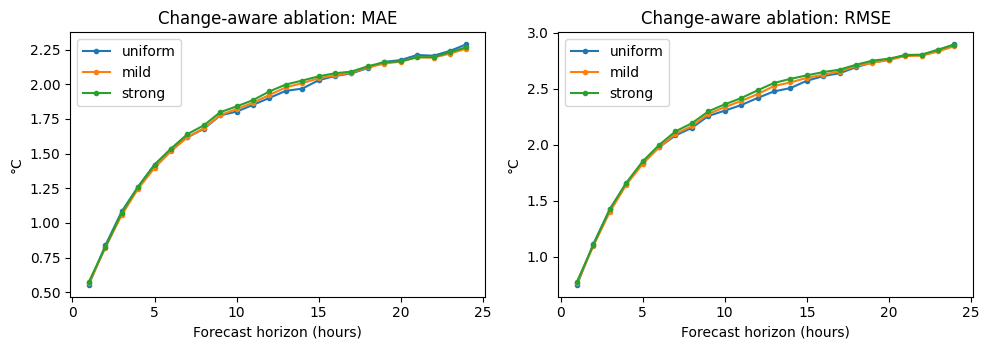

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

for name, pred in change_test_predictions.items():
    mae_h, rmse_h = horizon_metrics(pred, y_test_c)
    axes[0].plot(hx, mae_h, marker=".", label=name)
    axes[1].plot(hx, rmse_h, marker=".", label=name)

axes[0].set_title("Change-aware ablation: MAE")
axes[1].set_title("Change-aware ablation: RMSE")

for ax in axes:
    ax.set_xlabel("Forecast horizon (hours)")
    ax.set_ylabel("°C")
    ax.legend()

plt.tight_layout()
savefig("06_change_aware_ablation_horizon.png")
plt.show()

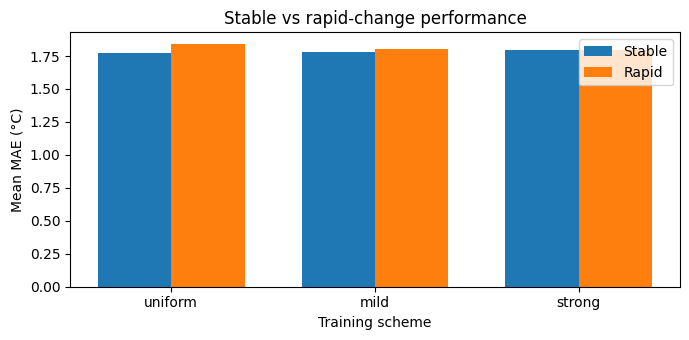

In [25]:
regime_plot_rows = []

for name, pred in change_test_predictions.items():
    sample_error = np.mean(np.abs(pred - y_test_c), axis=1)
    regime_plot_rows.append({"scheme": name, "regime": "Stable", "MAE": sample_error[stable_mask].mean()})
    regime_plot_rows.append({"scheme": name, "regime": "Rapid", "MAE": sample_error[rapid_mask].mean()})

regime_plot_df = pd.DataFrame(regime_plot_rows)

x = np.arange(len(weight_schemes))
width = 0.36

stable_values = regime_plot_df[regime_plot_df["regime"] == "Stable"]["MAE"].values
rapid_values = regime_plot_df[regime_plot_df["regime"] == "Rapid"]["MAE"].values

plt.figure(figsize=(7, 3.5))
plt.bar(x - width / 2, stable_values, width, label="Stable")
plt.bar(x + width / 2, rapid_values, width, label="Rapid")
plt.xticks(x, list(weight_schemes.keys()))
plt.ylabel("Mean MAE (°C)")
plt.xlabel("Training scheme")
plt.title("Stable vs rapid-change performance")
plt.legend()
plt.tight_layout()
savefig("07_change_aware_regime_comparison.png")
plt.show()

## 7. Statistical Hypothesis Testing
The primary comparison is **uniform GRU vs the validation-selected change-aware GRU** on rapid-change windows. Tests use non-overlapping forecast windows to limit serial dependence.

In [26]:
uniform_pred = change_test_predictions["uniform"]
selected_pred = change_test_predictions[selected_scheme]

uniform_error = np.mean(np.abs(uniform_pred - y_test_c), axis=1)
selected_error = np.mean(np.abs(selected_pred - y_test_c), axis=1)

infer_idx = stat_idx
infer_rapid = rapid_mask[infer_idx]
infer_stable = stable_mask[infer_idx]

rapid_uniform = uniform_error[infer_idx][infer_rapid]
rapid_selected = selected_error[infer_idx][infer_rapid]
stable_uniform = uniform_error[infer_idx][infer_stable]
stable_selected = selected_error[infer_idx][infer_stable]

print("Selected scheme:", selected_scheme)
print("Non-overlapping rapid windows:", len(rapid_uniform))
print("Non-overlapping stable windows:", len(stable_uniform))

Selected scheme: strong
Non-overlapping rapid windows: 22
Non-overlapping stable windows: 87


### 7.1 Primary rapid-regime test
The one-sided Wilcoxon signed-rank test evaluates whether the validation-selected change-aware method has lower paired MAE than uniform GRU training on rapid-change windows. The paired effect size is reported separately.


In [27]:
rapid_diff = selected_error[infer_idx][infer_rapid] - uniform_error[infer_idx][infer_rapid]

wilcoxon_rapid = stats.wilcoxon(rapid_selected, rapid_uniform, alternative="less")
cohen_dz = rapid_diff.mean() / rapid_diff.std(ddof=1) if rapid_diff.std(ddof=1) > 0 else np.nan

rapid_tests = pd.DataFrame([{
    "test": "Wilcoxon signed-rank, selected < uniform",
    "statistic": wilcoxon_rapid.statistic,
    "p_value": wilcoxon_rapid.pvalue,
    "purpose": "Primary hypothesis test"
}])

rapid_tests.round(6)


,test,statistic,p_value,purpose
0,"Wilcoxon signed-rank, selected < uniform",115.0,0.363092,Primary hypothesis test


### 7.2 Bootstrap confidence interval and practical effect
A paired bootstrap on the non-overlapping rapid-change evaluation windows estimates a 95% confidence interval for the mean MAE difference. Negative values favor change-aware training.

In [28]:
def paired_bootstrap_mean_ci(values, n_boot=5000, seed=SEED):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    n = len(values)
    estimates = np.empty(n_boot)
    for b in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        estimates[b] = sample.mean()
    return tuple(np.quantile(estimates, [0.025, 0.975]))

rapid_ci_low, rapid_ci_high = paired_bootstrap_mean_ci(rapid_diff)

rapid_improvement = rapid_uniform.mean() - rapid_selected.mean()
rapid_improvement_pct = 100 * rapid_improvement / rapid_uniform.mean()

print("Rapid MAE improvement (°C):", round(float(rapid_improvement), 4))
print("Rapid MAE improvement (%):", round(float(rapid_improvement_pct), 2))
print("95% paired-bootstrap CI for selected - uniform:", (round(float(rapid_ci_low), 4), round(float(rapid_ci_high), 4)))
print("Paired Cohen's dz:", round(float(cohen_dz), 4))

Rapid MAE improvement (°C): 0.0224
Rapid MAE improvement (%): 1.08
95% paired-bootstrap CI for selected - uniform: (-0.1909, 0.1427)
Paired Cohen's dz: -0.0548


### 7.3 Stable-regime cost
The stable regime is treated as a practical guardrail rather than a second hypothesis test. The intervention is acceptable only if stable-window MAE degradation remains within 5%.


In [29]:
stable_diff = stable_selected - stable_uniform

stable_cost = selected_error[stable_mask].mean() - uniform_error[stable_mask].mean()
stable_cost_pct = 100 * stable_cost / uniform_error[stable_mask].mean()

print("Stable MAE change (°C):", round(float(stable_cost), 4))
print("Stable MAE change (%):", round(float(stable_cost_pct), 2))


Stable MAE change (°C): 0.0251
Stable MAE change (%): 1.42


### 7.4 Final hypothesis decision
Support requires a significant one-sided Wilcoxon result in the rapid regime, a negative bootstrap CI for the mean paired rapid-regime difference, and stable-regime MAE degradation no greater than 5%.

In [30]:
primary_significant = wilcoxon_rapid.pvalue < 0.05
bootstrap_support = rapid_ci_high < 0
stable_guardrail = stable_cost_pct <= 5.0

supported = primary_significant and bootstrap_support and stable_guardrail

hypothesis_summary = pd.DataFrame([{
    "selected_scheme": selected_scheme,
    "rapid_MAE_uniform_nonoverlap": rapid_uniform.mean(),
    "rapid_MAE_selected_nonoverlap": rapid_selected.mean(),
    "rapid_improvement_pct_nonoverlap": rapid_improvement_pct,
    "wilcoxon_one_sided_p": wilcoxon_rapid.pvalue,
    "bootstrap_CI_low_selected_minus_uniform": rapid_ci_low,
    "bootstrap_CI_high_selected_minus_uniform": rapid_ci_high,
    "stable_MAE_change_pct_full_test": stable_cost_pct,
    "cohen_dz_rapid": cohen_dz,
    "hypothesis_supported": supported
}])

hypothesis_summary.to_csv(os.path.join(RES_DIR, "hypothesis_statistical_summary.csv"), index=False)
rapid_tests.to_csv(os.path.join(RES_DIR, "rapid_regime_statistical_tests.csv"), index=False)

print("HYPOTHESIS:", "SUPPORTED" if supported else "NOT SUPPORTED")
hypothesis_summary.round(5)


HYPOTHESIS: NOT SUPPORTED


,selected_scheme,rapid_MAE_uniform_nonoverlap,rapid_MAE_selected_nonoverlap,rapid_improvement_pct_nonoverlap,wilcoxon_one_sided_p,bootstrap_CI_low_selected_minus_uniform,bootstrap_CI_high_selected_minus_uniform,stable_MAE_change_pct_full_test,cohen_dz_rapid,hypothesis_supported
0,strong,2.08245,2.06,1.07792,0.36309,-0.19092,0.14271,1.41908,-0.05481,False


### 7.5 Multi-seed robustness
The primary comparison is repeated with three random seeds. The validation-selected weighting scheme is held fixed across seeds, so the test set is never used to choose the intervention. Mean and standard deviation summarize how sensitive the observed effect is to stochastic training.


In [31]:
ROBUST_SEEDS = [7, 21, 42]
robust_rows = []

for seed in ROBUST_SEEDS:
    uniform_seed, _ = train_model(
        build_gru,
        f"GRU_uniform_seed_{seed}",
        seed=seed
    )

    selected_seed, _ = train_model(
        build_gru,
        f"GRU_{selected_scheme}_seed_{seed}",
        sample_weight=train_weights[selected_scheme],
        seed=seed
    )

    pred_uniform_seed = predict_celsius(uniform_seed, X_test)
    pred_selected_seed = predict_celsius(selected_seed, X_test)

    err_uniform_seed = np.mean(
        np.abs(pred_uniform_seed - y_test_c),
        axis=1
    )

    err_selected_seed = np.mean(
        np.abs(pred_selected_seed - y_test_c),
        axis=1
    )

    robust_rows.append({
        "seed": seed,
        "uniform_MAE_overall": err_uniform_seed.mean(),
        "selected_MAE_overall": err_selected_seed.mean(),
        "delta_MAE_overall_selected_minus_uniform":
            err_selected_seed.mean() - err_uniform_seed.mean(),
        "uniform_MAE_rapid": err_uniform_seed[rapid_mask].mean(),
        "selected_MAE_rapid": err_selected_seed[rapid_mask].mean(),
        "delta_MAE_rapid_selected_minus_uniform":
            err_selected_seed[rapid_mask].mean()
            - err_uniform_seed[rapid_mask].mean()
    })

robustness = pd.DataFrame(robust_rows)

robustness.to_csv(
    os.path.join(
        RES_DIR,
        "change_aware_multiseed_robustness.csv"
    ),
    index=False
)

robust_summary = (
    robustness
    .drop(columns="seed")
    .agg(["mean", "std"])
    .T
)

robust_summary.to_csv(
    os.path.join(
        RES_DIR,
        "change_aware_multiseed_summary.csv"
    )
)

robust_summary.round(4)

Epoch 1/20
383/383 - 4s - 10ms/step - loss: 0.1747 - val_loss: 0.0975
Epoch 2/20
383/383 - 2s - 6ms/step - loss: 0.0885 - val_loss: 0.0884
Epoch 3/20
383/383 - 2s - 6ms/step - loss: 0.0819 - val_loss: 0.0855
Epoch 4/20
383/383 - 2s - 6ms/step - loss: 0.0783 - val_loss: 0.0839
Epoch 5/20
383/383 - 2s - 6ms/step - loss: 0.0756 - val_loss: 0.0830
Epoch 6/20
383/383 - 2s - 6ms/step - loss: 0.0735 - val_loss: 0.0825
Epoch 7/20
383/383 - 2s - 6ms/step - loss: 0.0716 - val_loss: 0.0821
Epoch 8/20
383/383 - 3s - 7ms/step - loss: 0.0698 - val_loss: 0.0820
Epoch 9/20
383/383 - 2s - 6ms/step - loss: 0.0680 - val_loss: 0.0819
Epoch 10/20
383/383 - 2s - 6ms/step - loss: 0.0662 - val_loss: 0.0821
Epoch 11/20
383/383 - 2s - 6ms/step - loss: 0.0643 - val_loss: 0.0828
Epoch 12/20
383/383 - 2s - 6ms/step - loss: 0.0625 - val_loss: 0.0836
Epoch 13/20
383/383 - 2s - 6ms/step - loss: 0.0606 - val_loss: 0.0847
Completed: GRU_uniform_seed_7
Training seconds: 33.62
Epoch 1/20
383/383 - 4s - 10ms/step - loss: 

,mean,std
uniform_MAE_overall,1.7829,0.0053
selected_MAE_overall,1.7939,0.0101
delta_MAE_overall_selected_minus_uniform,0.0111,0.0049
uniform_MAE_rapid,1.8180,0.0193
selected_MAE_rapid,1.7681,0.0233
delta_MAE_rapid_selected_minus_uniform,-0.0499,0.0088


## 8. Error Analysis

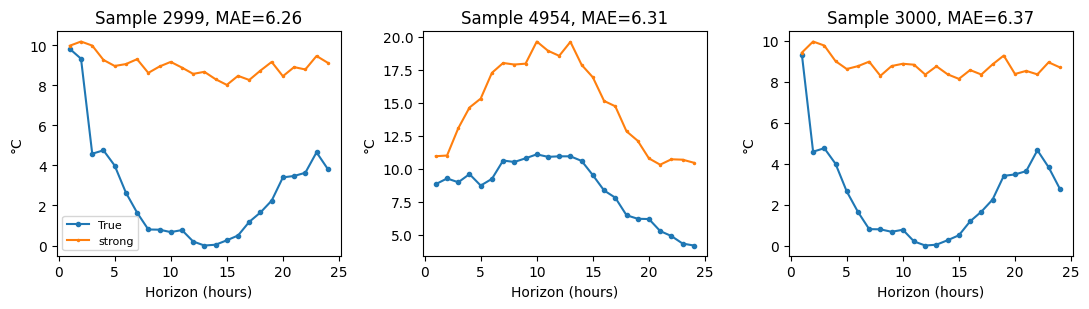

In [32]:
best_pred = selected_pred
best_error = selected_error
worst = np.argsort(best_error)[-3:]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, sample_id in zip(axes, worst):
    ax.plot(hx, y_test_c[sample_id], marker="o", ms=3, label="True")
    ax.plot(hx, best_pred[sample_id], marker=".", ms=3, label=selected_scheme)
    ax.set_title(f"Sample {sample_id}, MAE={best_error[sample_id]:.2f}")
    ax.set_xlabel("Horizon (hours)")
    ax.set_ylabel("°C")

axes[0].legend(fontsize=8)
plt.tight_layout()
savefig("08_worst_case_forecasts.png")
plt.show()

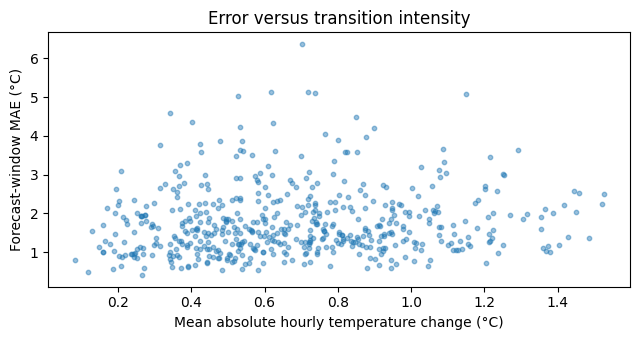

In [33]:
plt.figure(figsize=(6.5, 3.5))
plt.scatter(test_change[::20], best_error[::20], s=10, alpha=0.45)
plt.xlabel("Mean absolute hourly temperature change (°C)")
plt.ylabel("Forecast-window MAE (°C)")
plt.title("Error versus transition intensity")
plt.tight_layout()
savefig("09_error_vs_transition_intensity.png")
plt.show()

## 9. Supplementary Experiments for the Required Discussion Questions
These experiments are not the primary original contribution. They provide direct evidence for the two required Discussion & Observation questions.

### 9.1 Recurrent attention experiment
A GRU with additive attention over recurrent states is compared with the plain GRU under the same training budget.

In [34]:
def build_gru_attention():
    inp = layers.Input((IN_LEN, N_FEAT))
    sequence, state = layers.GRU(UNITS, return_sequences=True, return_state=True, name="gru_encoder")(inp)
    query = layers.Reshape((1, UNITS), name="attention_query")(state)
    context = layers.AdditiveAttention(name="temporal_attention")([query, sequence])
    context = layers.Flatten()(context)
    merged = layers.Concatenate()([state, context])
    out = layers.Dense(OUT_LEN)(merged)
    return keras.Model(inp, out, name="GRU_Attention")

attention_model, attention_hist = train_model(build_gru_attention, "GRU_Attention")
pred_attention_test = predict_celsius(attention_model, X_test)
attention_mae, attention_rmse = horizon_metrics(pred_attention_test, y_test_c)


Epoch 1/20
383/383 - 4s - 11ms/step - loss: 0.1559 - val_loss: 0.0948
Epoch 2/20
383/383 - 3s - 7ms/step - loss: 0.0857 - val_loss: 0.0884
Epoch 3/20
383/383 - 3s - 7ms/step - loss: 0.0791 - val_loss: 0.0857
Epoch 4/20
383/383 - 3s - 7ms/step - loss: 0.0755 - val_loss: 0.0839
Epoch 5/20
383/383 - 3s - 7ms/step - loss: 0.0730 - val_loss: 0.0833
Epoch 6/20
383/383 - 3s - 7ms/step - loss: 0.0709 - val_loss: 0.0833
Epoch 7/20
383/383 - 3s - 7ms/step - loss: 0.0690 - val_loss: 0.0836
Epoch 8/20
383/383 - 3s - 7ms/step - loss: 0.0672 - val_loss: 0.0839
Epoch 9/20
383/383 - 3s - 7ms/step - loss: 0.0654 - val_loss: 0.0841
Completed: GRU_Attention
Training seconds: 26.19


In [35]:
S = slice(0, 6)
L = slice(18, 24)

attention_comparison = pd.DataFrame([
    {
        "model": "GRU",
        "MAE_short_h1_6": baseline_metrics["GRU"][0][S].mean(),
        "MAE_long_h19_24": baseline_metrics["GRU"][0][L].mean(),
        "MAE_overall": baseline_metrics["GRU"][0].mean(),
        "RMSE_overall": baseline_metrics["GRU"][1].mean()
    },
    {
        "model": "GRU_Attention",
        "MAE_short_h1_6": attention_mae[S].mean(),
        "MAE_long_h19_24": attention_mae[L].mean(),
        "MAE_overall": attention_mae.mean(),
        "RMSE_overall": attention_rmse.mean()
    }
])

attention_comparison.to_csv(os.path.join(RES_DIR, "discussion_attention_comparison.csv"), index=False)
attention_comparison.round(4)

,model,MAE_short_h1_6,MAE_long_h19_24,MAE_overall,RMSE_overall
0,GRU,1.1145,2.2132,1.7832,2.2772
1,GRU_Attention,1.1494,2.2507,1.8131,2.2965


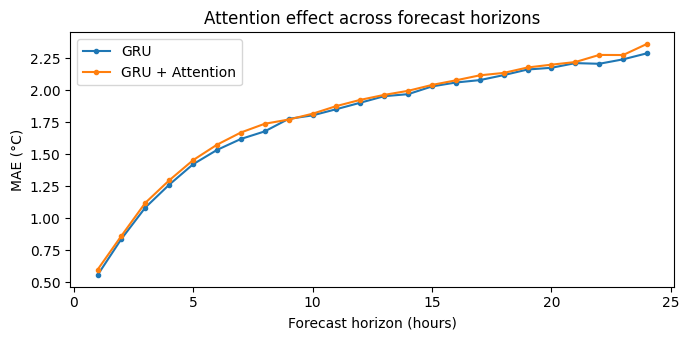

In [36]:
plt.figure(figsize=(7, 3.5))
plt.plot(hx, baseline_metrics["GRU"][0], marker=".", label="GRU")
plt.plot(hx, attention_mae, marker=".", label="GRU + Attention")
plt.xlabel("Forecast horizon (hours)")
plt.ylabel("MAE (°C)")
plt.title("Attention effect across forecast horizons")
plt.legend()
plt.tight_layout()
savefig("10_attention_vs_gru_horizon.png")
plt.show()

In [37]:
gru_long_error = np.mean(np.abs(pred_gru_test[stat_idx, L] - y_test_c[stat_idx, L]), axis=1)
att_long_error = np.mean(np.abs(pred_attention_test[stat_idx, L] - y_test_c[stat_idx, L]), axis=1)

attention_wilcoxon = stats.wilcoxon(att_long_error, gru_long_error, alternative="less")
attention_long_gain = gru_long_error.mean() - att_long_error.mean()

attention_test = pd.DataFrame([{
    "comparison": "GRU_Attention < GRU on h19-h24 MAE",
    "mean_long_MAE_GRU": gru_long_error.mean(),
    "mean_long_MAE_Attention": att_long_error.mean(),
    "mean_gain_degC": attention_long_gain,
    "wilcoxon_statistic": attention_wilcoxon.statistic,
    "p_value_one_sided": attention_wilcoxon.pvalue
}])

attention_test.to_csv(os.path.join(RES_DIR, "discussion_attention_statistical_test.csv"), index=False)
attention_test.round(5)

,comparison,mean_long_MAE_GRU,mean_long_MAE_Attention,mean_gain_degC,wilcoxon_statistic,p_value_one_sided
0,GRU_Attention < GRU on h19-h24 MAE,2.18367,2.22826,-0.04459,3177.0,0.70632


### 9.1.1 Attention-weight visualization
The trained attention model is inspected directly. Average attention over test windows shows which input lags receive the greatest weight, and a small heatmap shows how this pattern varies across individual forecasts. These are actual learned attention scores, not reconstruction- or error-based proxies.


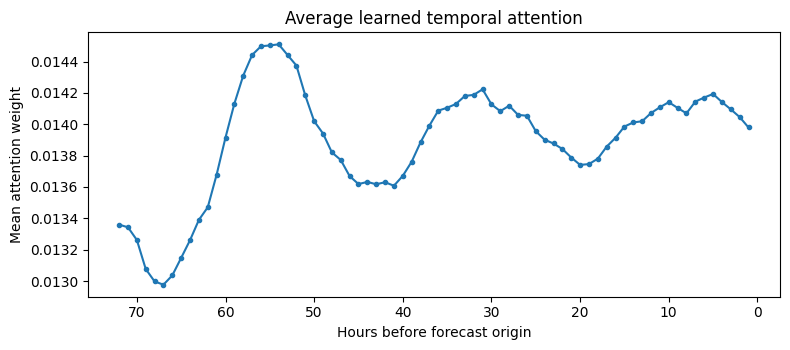

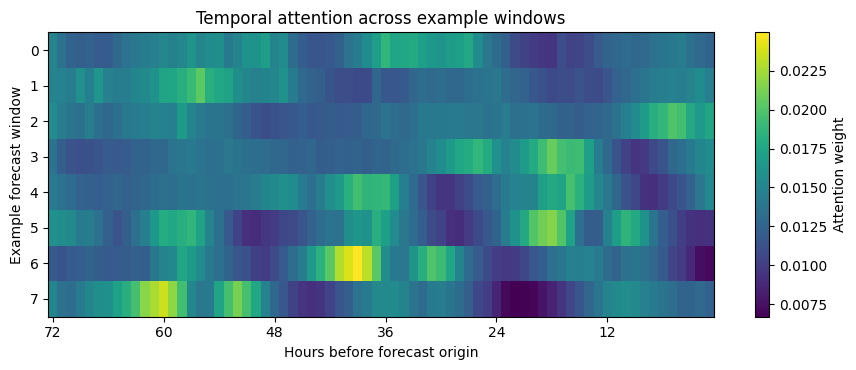

,hours_before_forecast,mean_attention_weight
18,54,0.01451
17,55,0.01450
16,56,0.01450
15,57,0.01444
19,53,0.01444
20,52,0.01437
14,58,0.01431
41,31,0.01422


In [38]:
sequence_output, _ = attention_model.get_layer("gru_encoder").output
query_output = attention_model.get_layer("attention_query").output
_, score_output = attention_model.get_layer("temporal_attention")(
    [query_output, sequence_output],
    return_attention_scores=True
)
attention_score_model = keras.Model(attention_model.input, score_output)

attention_idx = np.linspace(0, len(X_test) - 1, min(500, len(X_test)), dtype=int)
attention_scores = attention_score_model.predict(X_test[attention_idx], batch_size=256, verbose=0)[:, 0, :]
mean_attention = attention_scores.mean(axis=0)
lags = np.arange(IN_LEN, 0, -1)

attention_profile = pd.DataFrame({
    "hours_before_forecast": lags,
    "mean_attention_weight": mean_attention
})
attention_profile.to_csv(os.path.join(RES_DIR, "discussion_attention_weight_profile.csv"), index=False)

plt.figure(figsize=(8, 3.6))
plt.plot(lags, mean_attention, marker=".")
plt.gca().invert_xaxis()
plt.xlabel("Hours before forecast origin")
plt.ylabel("Mean attention weight")
plt.title("Average learned temporal attention")
plt.tight_layout()
savefig("10b_attention_weight_profile.png")
plt.show()

show_n = min(8, len(attention_scores))
plt.figure(figsize=(9, 3.8))
plt.imshow(attention_scores[:show_n], aspect="auto")
plt.colorbar(label="Attention weight")
plt.xticks(np.arange(0, IN_LEN, 12), lags[np.arange(0, IN_LEN, 12)])
plt.xlabel("Hours before forecast origin")
plt.ylabel("Example forecast window")
plt.title("Temporal attention across example windows")
plt.tight_layout()
savefig("10c_attention_weight_heatmap.png")
plt.show()

top_attention = attention_profile.nlargest(8, "mean_attention_weight")
top_attention.round(5)


### 9.2 Compact Transformer comparison
A small Transformer encoder is trained with the same input window, output horizon, optimizer, epoch cap, and early-stopping policy. It is included only to make the RNN-vs-Transformer discussion empirical.

In [39]:
D_MODEL = 64
NUM_HEADS = 4
FF_DIM = 128

def build_transformer():
    inp = layers.Input((IN_LEN, N_FEAT))
    x = layers.Dense(D_MODEL)(inp)
    positions = tf.range(start=0, limit=IN_LEN, delta=1)
    pos = layers.Embedding(input_dim=IN_LEN, output_dim=D_MODEL)(positions)
    x = x + pos
    attn = layers.MultiHeadAttention(num_heads=NUM_HEADS, key_dim=D_MODEL // NUM_HEADS)(x, x)
    x = layers.LayerNormalization()(x + attn)
    ff = layers.Dense(FF_DIM, activation="relu")(x)
    ff = layers.Dense(D_MODEL)(ff)
    x = layers.LayerNormalization()(x + ff)
    x = layers.GlobalAveragePooling1D()(x)
    out = layers.Dense(OUT_LEN)(x)
    return keras.Model(inp, out, name="Transformer")

transformer_model, transformer_hist = train_model(build_transformer, "Transformer")
pred_transformer_test = predict_celsius(transformer_model, X_test)
transformer_mae, transformer_rmse = horizon_metrics(pred_transformer_test, y_test_c)

Epoch 1/20


I0000 00:00:1786792727.576401     136 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


383/383 - 12s - 33ms/step - loss: 0.2886 - val_loss: 0.2445
Epoch 2/20
383/383 - 2s - 5ms/step - loss: 0.2287 - val_loss: 0.2455
Epoch 3/20
383/383 - 2s - 5ms/step - loss: 0.2168 - val_loss: 0.2453
Epoch 4/20
383/383 - 2s - 5ms/step - loss: 0.2086 - val_loss: 0.2423
Epoch 5/20
383/383 - 2s - 5ms/step - loss: 0.2026 - val_loss: 0.2409
Epoch 6/20
383/383 - 2s - 5ms/step - loss: 0.1977 - val_loss: 0.2391
Epoch 7/20
383/383 - 2s - 5ms/step - loss: 0.1927 - val_loss: 0.2376
Epoch 8/20
383/383 - 2s - 5ms/step - loss: 0.1875 - val_loss: 0.2379
Epoch 9/20
383/383 - 2s - 5ms/step - loss: 0.1821 - val_loss: 0.2385
Epoch 10/20
383/383 - 2s - 5ms/step - loss: 0.1759 - val_loss: 0.2367
Epoch 11/20
383/383 - 2s - 5ms/step - loss: 0.1686 - val_loss: 0.2349
Epoch 12/20
383/383 - 2s - 5ms/step - loss: 0.1580 - val_loss: 0.2229
Epoch 13/20
383/383 - 2s - 5ms/step - loss: 0.1417 - val_loss: 0.2088
Epoch 14/20
383/383 - 2s - 5ms/step - loss: 0.1258 - val_loss: 0.1787
Epoch 15/20
383/383 - 2s - 5ms/step - 

In [40]:
rnn_val_models = {
    "LSTM": lstm_model,
    "GRU": gru_model,
    "Seq2Seq": seq2seq_model
}

rnn_val_mae = {}
for name, model in rnn_val_models.items():
    pred = predict_celsius(model, X_val)
    rnn_val_mae[name] = np.mean(np.abs(pred - y_val_c))

best_rnn_name = min(rnn_val_mae, key=rnn_val_mae.get)
best_rnn_model = rnn_val_models[best_rnn_name]
best_rnn_test_pred = baseline_predictions[best_rnn_name]

print("Validation-selected RNN:", best_rnn_name)
print(pd.Series(rnn_val_mae).round(4))

Validation-selected RNN: GRU
LSTM       1.8872
GRU        1.8652
Seq2Seq    1.9588
dtype: float32


In [41]:
best_rnn_mae, best_rnn_rmse = baseline_metrics[best_rnn_name]

transformer_comparison = pd.DataFrame([
    {
        "model": best_rnn_name,
        "MAE_mean": best_rnn_mae.mean(),
        "RMSE_mean": best_rnn_rmse.mean(),
        "parameters": best_rnn_model.count_params(),
        "training_seconds": training_seconds[best_rnn_name]
    },
    {
        "model": "Transformer",
        "MAE_mean": transformer_mae.mean(),
        "RMSE_mean": transformer_rmse.mean(),
        "parameters": transformer_model.count_params(),
        "training_seconds": training_seconds["Transformer"]
    }
])

transformer_comparison.to_csv(os.path.join(RES_DIR, "discussion_rnn_vs_transformer.csv"), index=False)
transformer_comparison.round(4)

,model,MAE_mean,RMSE_mean,parameters,training_seconds
0,GRU,1.7832,2.2772,16920,28.8888
1,Transformer,2.6733,3.4306,35992,51.3644


In [42]:
best_rnn_sample_mae = np.mean(np.abs(best_rnn_test_pred[stat_idx] - y_test_c[stat_idx]), axis=1)
transformer_sample_mae = np.mean(np.abs(pred_transformer_test[stat_idx] - y_test_c[stat_idx]), axis=1)

rnn_transformer_wilcoxon = stats.wilcoxon(
    transformer_sample_mae,
    best_rnn_sample_mae,
    alternative="two-sided"
)

rnn_transformer_test = pd.DataFrame([{
    "comparison": f"Transformer vs {best_rnn_name}",
    "mean_MAE_RNN": best_rnn_sample_mae.mean(),
    "mean_MAE_Transformer": transformer_sample_mae.mean(),
    "wilcoxon_statistic": rnn_transformer_wilcoxon.statistic,
    "p_value_two_sided": rnn_transformer_wilcoxon.pvalue
}])

rnn_transformer_test.to_csv(os.path.join(RES_DIR, "discussion_rnn_vs_transformer_test.csv"), index=False)
rnn_transformer_test.round(5)

,comparison,mean_MAE_RNN,mean_MAE_Transformer,wilcoxon_statistic,p_value_two_sided
0,Transformer vs GRU,1.71813,2.58339,1376.0,0.0


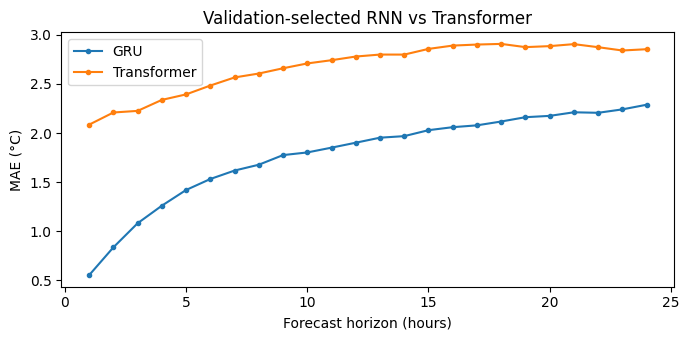

In [43]:
plt.figure(figsize=(7, 3.5))
plt.plot(hx, best_rnn_mae, marker=".", label=best_rnn_name)
plt.plot(hx, transformer_mae, marker=".", label="Transformer")
plt.xlabel("Forecast horizon (hours)")
plt.ylabel("MAE (°C)")
plt.title("Validation-selected RNN vs Transformer")
plt.legend()
plt.tight_layout()
savefig("11_rnn_vs_transformer_horizon.png")
plt.show()

### 9.3 Data-size and sequence-length regime sweep
To answer the second Discussion & Observation question empirically, the GRU and compact Transformer are compared across two training-data budgets (25% and 100%) and three input-history lengths (24, 72, and 168 hours). The validation split is used for this regime study so the test set remains reserved for final evaluation. Within every configuration, both architectures receive the same optimizer, epoch cap, batch size, and early-stopping policy.

In [44]:
REGIME_DATA_FRACTIONS = [0.25, 1.00]
REGIME_INPUT_LENGTHS = [24, 72, 168]
REGIME_EPOCHS = 12
REGIME_PATIENCE = 3

def build_regime_gru(in_len, n_feat):
    return keras.Sequential([
        layers.Input((in_len, n_feat)),
        layers.GRU(UNITS),
        layers.Dense(OUT_LEN)
    ], name=f"GRU_L{in_len}")

def build_regime_transformer(in_len, n_feat):
    inp = layers.Input((in_len, n_feat))
    x = layers.Dense(D_MODEL)(inp)
    positions = tf.range(start=0, limit=in_len, delta=1)
    pos = layers.Embedding(input_dim=in_len, output_dim=D_MODEL)(positions)
    x = x + pos
    attn = layers.MultiHeadAttention(num_heads=NUM_HEADS, key_dim=D_MODEL // NUM_HEADS)(x, x)
    x = layers.LayerNormalization()(x + attn)
    ff = layers.Dense(FF_DIM, activation="relu")(x)
    ff = layers.Dense(D_MODEL)(ff)
    x = layers.LayerNormalization()(x + ff)
    x = layers.GlobalAveragePooling1D()(x)
    out = layers.Dense(OUT_LEN)(x)
    return keras.Model(inp, out, name=f"Transformer_L{in_len}")

def train_regime_model(model, x_train, y_train_local, x_val, y_val_local, seed):
    reset_seeds(seed)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    callback = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=REGIME_PATIENCE,
        restore_best_weights=True
    )
    start = time.perf_counter()
    history = model.fit(
        x_train,
        y_train_local,
        validation_data=(x_val, y_val_local),
        epochs=REGIME_EPOCHS,
        batch_size=BATCH,
        callbacks=[callback],
        verbose=0
    )
    elapsed = time.perf_counter() - start
    pred = to_celsius(model.predict(x_val, batch_size=256, verbose=0))
    truth = to_celsius(y_val_local)
    mae, rmse = horizon_metrics(pred, truth)
    return float(mae.mean()), float(rmse.mean()), elapsed, len(history.history["loss"])

regime_rows = []

for in_len in REGIME_INPUT_LENGTHS:
    x_train_all, y_train_all = make_windows(train_s, in_len, OUT_LEN, target_idx)
    x_val_regime, y_val_regime = make_windows(val_s, in_len, OUT_LEN, target_idx)

    for fraction in REGIME_DATA_FRACTIONS:
        n_use = max(1, int(round(len(x_train_all) * fraction)))
        train_idx = np.linspace(0, len(x_train_all) - 1, n_use, dtype=int)
        x_train_regime = x_train_all[train_idx]
        y_train_regime = y_train_all[train_idx]

        for model_name in ["GRU", "Transformer"]:
            seed = SEED + in_len + int(fraction * 100) + (0 if model_name == "GRU" else 1000)
            reset_seeds(seed)
            if model_name == "GRU":
                model = build_regime_gru(in_len, x_train_regime.shape[-1])
            else:
                model = build_regime_transformer(in_len, x_train_regime.shape[-1])

            val_mae, val_rmse, elapsed, epochs_ran = train_regime_model(
                model, x_train_regime, y_train_regime, x_val_regime, y_val_regime, seed
            )

            regime_rows.append({
                "train_fraction": fraction,
                "train_windows": n_use,
                "input_hours": in_len,
                "model": model_name,
                "val_MAE": val_mae,
                "val_RMSE": val_rmse,
                "parameters": model.count_params(),
                "training_seconds": elapsed,
                "epochs_ran": epochs_ran
            })

            del model

regime_results = pd.DataFrame(regime_rows)
regime_results.to_csv(os.path.join(RES_DIR, "discussion_rnn_transformer_regime_sweep.csv"), index=False)
regime_results.round(4)

,train_fraction,train_windows,input_hours,model,val_MAE,val_RMSE,parameters,training_seconds,epochs_ran
0,0.25,12254,24,GRU,1.9463,2.5337,16920,10.3855,12
1,0.25,12254,24,Transformer,2.6825,3.4267,35992,17.4683,12
2,1.00,49016,24,GRU,1.8735,2.4456,16920,25.7393,12
3,1.00,49016,24,Transformer,2.3378,3.0121,35992,26.8739,12
4,0.25,12242,72,GRU,1.9030,2.4718,16920,12.0954,12
5,0.25,12242,72,Transformer,3.4043,4.2958,35992,14.5719,7
6,1.00,48968,72,GRU,1.8793,2.4267,16920,28.8564,11
7,1.00,48968,72,Transformer,3.3708,4.2952,35992,19.9019,5
8,0.25,12218,168,GRU,1.9367,2.5101,16920,16.2445,12
9,0.25,12218,168,Transformer,3.6147,4.6166,35992,18.1524,5


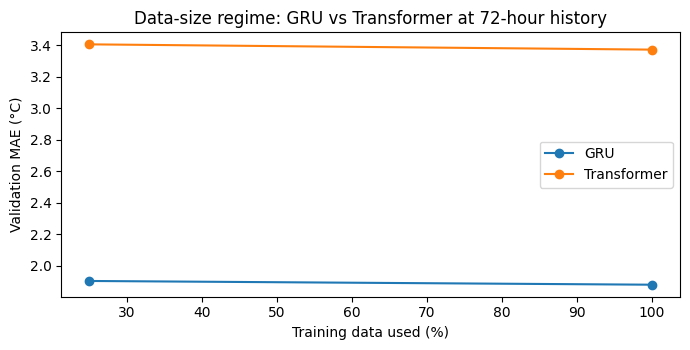

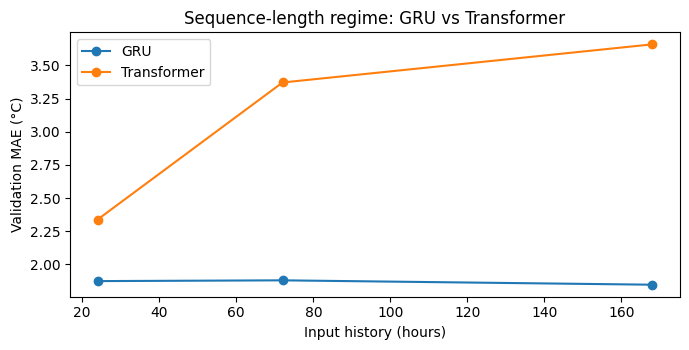

model,train_fraction,input_hours,GRU,Transformer,Transformer_minus_GRU_MAE
0,0.25,24,1.9463,2.6825,0.7362
1,0.25,72,1.9030,3.4043,1.5013
2,0.25,168,1.9367,3.6147,1.6780
3,1.00,24,1.8735,2.3378,0.4643
4,1.00,72,1.8793,3.3708,1.4916
5,1.00,168,1.8463,3.6585,1.8122


In [45]:
regime_pivot = regime_results.pivot_table(
    index=["train_fraction", "input_hours"],
    columns="model",
    values="val_MAE"
).reset_index()
regime_pivot["Transformer_minus_GRU_MAE"] = regime_pivot["Transformer"] - regime_pivot["GRU"]
regime_pivot.to_csv(os.path.join(RES_DIR, "discussion_rnn_transformer_regime_gaps.csv"), index=False)

fig_data = regime_results[regime_results["input_hours"] == 72]
plt.figure(figsize=(7, 3.6))
for model_name in ["GRU", "Transformer"]:
    subset = fig_data[fig_data["model"] == model_name].sort_values("train_fraction")
    plt.plot(subset["train_fraction"] * 100, subset["val_MAE"], marker="o", label=model_name)
plt.xlabel("Training data used (%)")
plt.ylabel("Validation MAE (°C)")
plt.title("Data-size regime: GRU vs Transformer at 72-hour history")
plt.legend()
plt.tight_layout()
savefig("11b_rnn_transformer_data_size_sweep.png")
plt.show()

fig_length = regime_results[regime_results["train_fraction"] == 1.0]
plt.figure(figsize=(7, 3.6))
for model_name in ["GRU", "Transformer"]:
    subset = fig_length[fig_length["model"] == model_name].sort_values("input_hours")
    plt.plot(subset["input_hours"], subset["val_MAE"], marker="o", label=model_name)
plt.xlabel("Input history (hours)")
plt.ylabel("Validation MAE (°C)")
plt.title("Sequence-length regime: GRU vs Transformer")
plt.legend()
plt.tight_layout()
savefig("11c_rnn_transformer_sequence_length_sweep.png")
plt.show()

regime_pivot.round(4)

### 9.4 Stretch bonus — Empirical prediction intervals
A lightweight probabilistic extension is built from validation residuals of the validation-selected change-aware GRU. Horizon-specific residual quantiles form 90% empirical prediction intervals around each point forecast. Interval quality is evaluated only on the test set using empirical coverage and mean interval width.


Overall empirical coverage: 0.9189
Mean interval width (°C): 8.0395


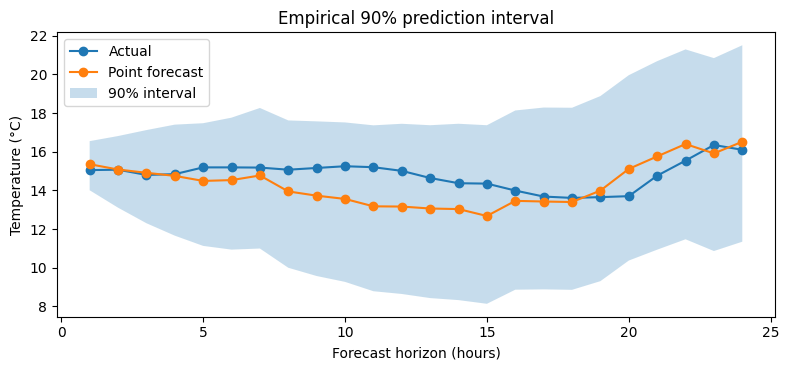

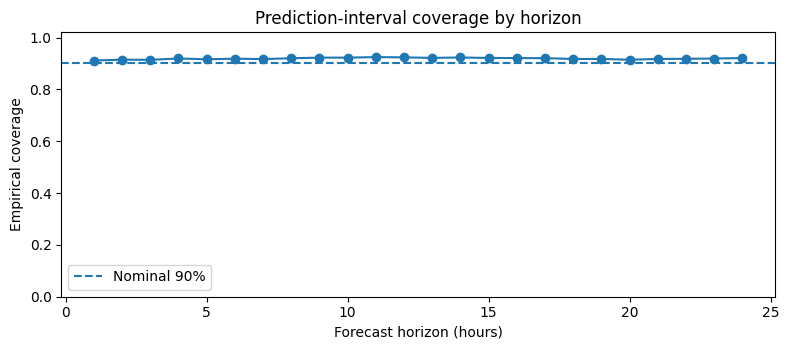

In [46]:
selected_val_pred = change_val_predictions[selected_scheme]
val_residuals = y_val_c - selected_val_pred

LOWER_Q = 0.05
UPPER_Q = 0.95
residual_low = np.quantile(val_residuals, LOWER_Q, axis=0)
residual_high = np.quantile(val_residuals, UPPER_Q, axis=0)

point_test = selected_pred
lower_test = point_test + residual_low
upper_test = point_test + residual_high

covered = (y_test_c >= lower_test) & (y_test_c <= upper_test)
coverage_h = covered.mean(axis=0)
width_h = (upper_test - lower_test).mean(axis=0)

interval_summary = pd.DataFrame({
    "horizon_hour": hx,
    "coverage_90": coverage_h,
    "mean_interval_width_degC": width_h
})
interval_summary.to_csv(os.path.join(RES_DIR, "stretch_prediction_intervals.csv"), index=False)

print("Overall empirical coverage:", round(float(covered.mean()), 4))
print("Mean interval width (°C):", round(float((upper_test - lower_test).mean()), 4))
interval_summary.round(4)

example_id = min(500, len(point_test) - 1)
plt.figure(figsize=(8, 3.8))
plt.plot(hx, y_test_c[example_id], marker="o", label="Actual")
plt.plot(hx, point_test[example_id], marker="o", label="Point forecast")
plt.fill_between(hx, lower_test[example_id], upper_test[example_id], alpha=0.25, label="90% interval")
plt.xlabel("Forecast horizon (hours)")
plt.ylabel("Temperature (°C)")
plt.title("Empirical 90% prediction interval")
plt.legend()
plt.tight_layout()
savefig("12_prediction_interval_example.png")
plt.show()

plt.figure(figsize=(8, 3.6))
plt.plot(hx, coverage_h, marker="o")
plt.axhline(0.90, linestyle="--", label="Nominal 90%")
plt.ylim(0, 1.02)
plt.xlabel("Forecast horizon (hours)")
plt.ylabel("Empirical coverage")
plt.title("Prediction-interval coverage by horizon")
plt.legend()
plt.tight_layout()
savefig("13_prediction_interval_coverage.png")
plt.show()


## 10. Discussion & Observation — Required Questions

### 10.1 Question 1 — What would recurrent attention look back at?
The answer below uses the attention experiment above rather than only a generic theoretical statement.

In [47]:
gru_short = baseline_metrics["GRU"][0][S].mean()
gru_long = baseline_metrics["GRU"][0][L].mean()
att_short = attention_mae[S].mean()
att_long = attention_mae[L].mean()

short_gain = gru_short - att_short
long_gain = gru_long - att_long

if long_gain > short_gain:
    horizon_statement = "The gain was larger at long horizons."
else:
    horizon_statement = "The gain was not larger at long horizons."

top_lags = top_attention.sort_values("mean_attention_weight", ascending=False)["hours_before_forecast"].astype(int).tolist()[:5]

print(
    f"Plain GRU MAE rose from {baseline_metrics['GRU'][0][0]:.3f}°C at h=1 "
    f"to {baseline_metrics['GRU'][0][-1]:.3f}°C at h=24. "
    f"With additive attention, mean MAE was {att_short:.3f}°C for h1-h6 "
    f"and {att_long:.3f}°C for h19-h24, compared with {gru_short:.3f}°C "
    f"and {gru_long:.3f}°C for the plain GRU. {horizon_statement} "
    f"The long-horizon one-sided Wilcoxon p-value was {attention_wilcoxon.pvalue:.4g}. "
    f"The largest average learned attention weights occurred around lags {top_lags} hours before the forecast origin. "
    "These weights show what the trained model actually revisits in the 72-hour history, while their forecasting value must still be judged by the error comparison rather than by visual prominence alone."
)


Plain GRU MAE rose from 0.554°C at h=1 to 2.288°C at h=24. With additive attention, mean MAE was 1.149°C for h1-h6 and 2.251°C for h19-h24, compared with 1.115°C and 2.213°C for the plain GRU. The gain was not larger at long horizons. The long-horizon one-sided Wilcoxon p-value was 0.7063. The largest average learned attention weights occurred around lags [54, 55, 56, 57, 53] hours before the forecast origin. These weights show what the trained model actually revisits in the 72-hour history, while their forecasting value must still be judged by the error comparison rather than by visual prominence alone.


### 10.2 Question 2 — What does the RNN inductive bias buy us?
The answer below combines the matched final-task comparison with the validation-only data-size and sequence-length regime sweep, so the claim about when to prefer an RNN is based on observed behavior rather than theory alone.

In [52]:
rnn_row = transformer_comparison.iloc[0]
tr_row = transformer_comparison.iloc[1]

small_data = regime_pivot[regime_pivot["train_fraction"] == REGIME_DATA_FRACTIONS[0]].copy()
full_data = regime_pivot[regime_pivot["train_fraction"] == 1.0].copy()

small_data_wins = int((small_data["Transformer_minus_GRU_MAE"] > 0).sum())
full_data_wins = int((full_data["Transformer_minus_GRU_MAE"] > 0).sum())

short_row = full_data.loc[full_data["input_hours"].idxmin()]
mid_row = full_data.iloc[(full_data["input_hours"] - 72).abs().argsort()[:1]].iloc[0]
long_row = full_data.loc[full_data["input_hours"].idxmax()]

short_gap = float(short_row["Transformer_minus_GRU_MAE"])
mid_gap = float(mid_row["Transformer_minus_GRU_MAE"])
long_gap = float(long_row["Transformer_minus_GRU_MAE"])

print(
    f"In the matched main-task comparison, {best_rnn_name} achieved lower mean MAE than the Transformer "
    f"and also trained {'faster' if rnn_row['training_seconds'] < tr_row['training_seconds'] else 'more slowly'} "
    f"under the same notebook budget. The paired Wilcoxon test gave "
    f"p={rnn_transformer_wilcoxon.pvalue:.4g}. "
    f"The regime sweep strengthened this result: the GRU achieved lower validation MAE in "
    f"{small_data_wins}/{len(small_data)} settings with 25% of the training data and "
    f"{full_data_wins}/{len(full_data)} settings with the full training set. "
    f"With full data, the Transformer-minus-GRU MAE gap was {short_gap:.3f}°C at "
    f"{int(short_row['input_hours'])} hours of history, {mid_gap:.3f}°C at "
    f"{int(mid_row['input_hours'])} hours, and {long_gap:.3f}°C at "
    f"{int(long_row['input_hours'])} hours. "
    "Therefore, in this dataset and training budget, the RNN's sequential inductive bias was useful "
    "not only in the reduced-data regime but across all tested data sizes and sequence lengths. "
    "Its advantage was especially pronounced for the longer input histories, where the Transformer "
    "did not close the error gap. These results suggest that the GRU is the safer choice for this "
    "moderate-sized weather dataset under the tested 24-168 hour context range. "
    "This conclusion is specific to the tested regimes; substantially larger datasets, longer contexts, "
    "or more extensively tuned Transformer architectures could change the comparison."
)

In the matched main-task comparison, GRU achieved lower mean MAE than the Transformer and also trained faster under the same notebook budget. The paired Wilcoxon test gave p=9.477e-07. The regime sweep strengthened this result: the GRU achieved lower validation MAE in 3/3 settings with 25% of the training data and 3/3 settings with the full training set. With full data, the Transformer-minus-GRU MAE gap was 0.464°C at 24 hours of history, 1.492°C at 72 hours, and 1.812°C at 168 hours. Therefore, in this dataset and training budget, the RNN's sequential inductive bias was useful not only in the reduced-data regime but across all tested data sizes and sequence lengths. Its advantage was especially pronounced for the longer input histories, where the Transformer did not close the error gap. These results suggest that the GRU is the safer choice for this moderate-sized weather dataset under the tested 24-168 hour context range. This conclusion is specific to the tested regimes; substantial

### 10.3 Statistical interpretation
The statistical analysis focuses on tests that answer a specific experimental question: Friedman plus Holm-adjusted Wilcoxon comparisons for the baseline model family, Spearman correlation for the diagnosed failure mode, a one-sided paired Wilcoxon test with bootstrap confidence interval and effect size for the primary contribution, and targeted paired Wilcoxon tests for the attention and main RNN-vs-Transformer comparison. The data-size and sequence-length sweep is treated as a validation-only regime analysis rather than as an additional test-set significance exercise. Practical effect size and uncertainty are kept separate from statistical significance.

## 11. Limitations
Hourly subsampling removes some short-scale dynamics; the study uses one station, one target, and compact model configurations. Multi-seed evaluation reduces dependence on one stochastic training run but remains limited to three seeds. Non-overlapping windows reduce dependence in hypothesis tests but do not guarantee complete independence. The RNN-vs-Transformer regime sweep uses two data budgets and three input lengths, so it supports only local conclusions about these tested regimes rather than a universal architecture ranking. The residual-based prediction intervals are empirical marginal intervals calibrated on validation residuals; they do not model a full conditional predictive distribution.

## 12. Reproducibility and Outputs

In [49]:
selected_model_path = os.path.join(MODEL_DIR, f"gru_{selected_scheme}_change_aware.keras")
change_models[selected_scheme].save(selected_model_path)
attention_model.save(os.path.join(MODEL_DIR, "gru_attention.keras"))
transformer_model.save(os.path.join(MODEL_DIR, "transformer_baseline.keras"))

print("Figures:", FIG_DIR)
print(*sorted(os.listdir(FIG_DIR)), sep="\n")
print("\nResults:", RES_DIR)
print(*sorted(os.listdir(RES_DIR)), sep="\n")
print("\nModels:", MODEL_DIR)
print(*sorted(os.listdir(MODEL_DIR)), sep="\n")

Figures: /kaggle/working/figures
01_temperature_timeseries.png
02_training_curves.png
03_baseline_metrics_vs_horizon.png
04_example_forecasts.png
05_error_by_change_regime.png
06_change_aware_ablation_horizon.png
07_change_aware_regime_comparison.png
08_worst_case_forecasts.png
09_error_vs_transition_intensity.png
10_attention_vs_gru_horizon.png
10b_attention_weight_profile.png
10c_attention_weight_heatmap.png
11_rnn_vs_transformer_horizon.png
11b_rnn_transformer_data_size_sweep.png
11c_rnn_transformer_sequence_length_sweep.png
12_prediction_interval_example.png
13_prediction_interval_coverage.png

Results: /kaggle/working/results
baseline_metrics_per_horizon.csv
baseline_pairwise_wilcoxon_holm.csv
baseline_summary.csv
change_aware_multiseed_robustness.csv
change_aware_multiseed_summary.csv
change_aware_test_ablation.csv
change_aware_validation_selection.csv
discussion_attention_comparison.csv
discussion_attention_statistical_test.csv
discussion_attention_weight_profile.csv
discussion_

In [50]:
ZIP_PATH = "/kaggle/working/project1_figures"

shutil.make_archive(
    ZIP_PATH,
    "zip",
    FIG_DIR
)

print("ZIP created:")
print(ZIP_PATH + ".zip")
print("\nFiles included:")
print(*sorted(os.listdir(FIG_DIR)), sep="\n")


ZIP created:
/kaggle/working/project1_figures.zip

Files included:
01_temperature_timeseries.png
02_training_curves.png
03_baseline_metrics_vs_horizon.png
04_example_forecasts.png
05_error_by_change_regime.png
06_change_aware_ablation_horizon.png
07_change_aware_regime_comparison.png
08_worst_case_forecasts.png
09_error_vs_transition_intensity.png
10_attention_vs_gru_horizon.png
10b_attention_weight_profile.png
10c_attention_weight_heatmap.png
11_rnn_vs_transformer_horizon.png
11b_rnn_transformer_data_size_sweep.png
11c_rnn_transformer_sequence_length_sweep.png
12_prediction_interval_example.png
13_prediction_interval_coverage.png


In [51]:
PACK_DIR = "/kaggle/working/project1_presentation_files"

if os.path.exists(PACK_DIR):
    shutil.rmtree(PACK_DIR)

os.makedirs(os.path.join(PACK_DIR, "results"), exist_ok=True)
os.makedirs(os.path.join(PACK_DIR, "models"), exist_ok=True)

result_files = [
    "baseline_summary.csv",
    "baseline_metrics_per_horizon.csv",
    "baseline_pairwise_wilcoxon_holm.csv",
    "change_aware_test_ablation.csv",
    "hypothesis_statistical_summary.csv",
    "rapid_regime_statistical_tests.csv",
    "failure_mode_statistical_tests.csv",
    "change_aware_multiseed_robustness.csv",
    "change_aware_multiseed_summary.csv",
    "discussion_attention_comparison.csv",
    "discussion_attention_statistical_test.csv",
    "discussion_attention_weight_profile.csv",
    "discussion_rnn_vs_transformer.csv",
    "discussion_rnn_vs_transformer_test.csv",
    "discussion_rnn_transformer_regime_sweep.csv",
    "discussion_rnn_transformer_regime_gaps.csv",
    "stretch_prediction_intervals.csv",
]

model_files = [
    os.path.basename(selected_model_path),
    "gru_attention.keras",
    "transformer_baseline.keras",
]

for filename in result_files:
    src = os.path.join(RES_DIR, filename)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(PACK_DIR, "results", filename))

for filename in model_files:
    src = os.path.join(MODEL_DIR, filename)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(PACK_DIR, "models", filename))

zip_path = shutil.make_archive(
    "/kaggle/working/project1_presentation_files",
    "zip",
    PACK_DIR
)

print("Created:")
print(zip_path)


Created:
/kaggle/working/project1_presentation_files.zip
